<div style="background-color:#1a1a2e; padding:20px; border-radius:10px;">
<h1 style="color:#e94560; text-align:center;">📈 Part 1 — Regression</h1>
<h3 style="color:#ffffff; text-align:center;">Athlete Performance Score Prediction — DS301</h3>
<p style="color:#a8a8b3; text-align:center;">
Dataset: <a href="https://www.kaggle.com/datasets/zara2099/athlete-performance-evaluation-dataset" style="color:#00b4d8;">Kaggle — Athlete Performance Evaluation</a><br>
Target: performance_score (continuous) · Models: LR · Lasso · Ridge · SVR · DT · RF · NN
</p>
</div>

<div style="background-color:#0f3460; padding:15px; border-radius:10px; border-left:6px solid #e94560;">
<h2 style="color:#ffffff; margin:0;">📦 Step 1 — Imports & Setup</h2>
<p style="color:#a8d8ea; margin:5px 0 0 0;">Load all required libraries · Create results folder</p>
</div>

In [3]:
# ============================================================
# PART 1 — REGRESSION
# Dataset: Athlete Performance Evaluation
# Source: https://www.kaggle.com/datasets/zara2099/athlete-performance-evaluation-dataset
# Target: performance_score (continuous numeric)
# ============================================================
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

os.makedirs('results', exist_ok=True)
print("✅ All imports successful!")
print("Python version is compatible ✅")

✅ All imports successful!
Python version is compatible ✅


<div style="background-color:#533483; padding:15px; border-radius:10px; border-left:6px solid #ffcc00;">
<h2 style="color:#ffffff; margin:0;">🔍 Step 2 — Load & Explore Dataset</h2>
<p style="color:#f0e6ff; margin:5px 0 0 0;">Read CSV · Check shape, dtypes, missing values · Target variable stats</p>
</div>

DATASET OVERVIEW
Shape: (1000, 20)

Column names:
['timestamp', 'heart_rate', 'oxygen_saturation', 'respiration_rate', 'body_temperature', 'hydration_level', 'speed', 'acceleration', 'endurance_score', 'agility_score', 'reaction_time', 'workload', 'fatigue_index', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'performance_score', 'performance_category']

Data types:
timestamp                   str
heart_rate              float64
oxygen_saturation       float64
respiration_rate        float64
body_temperature        float64
hydration_level         float64
speed                   float64
acceleration            float64
endurance_score         float64
agility_score           float64
reaction_time           float64
workload                float64
fatigue_index           float64
feature_1               float64
feature_2               float64
feature_3               float64
feature_4               float64
feature_5               float64
performance_score       float64
perf

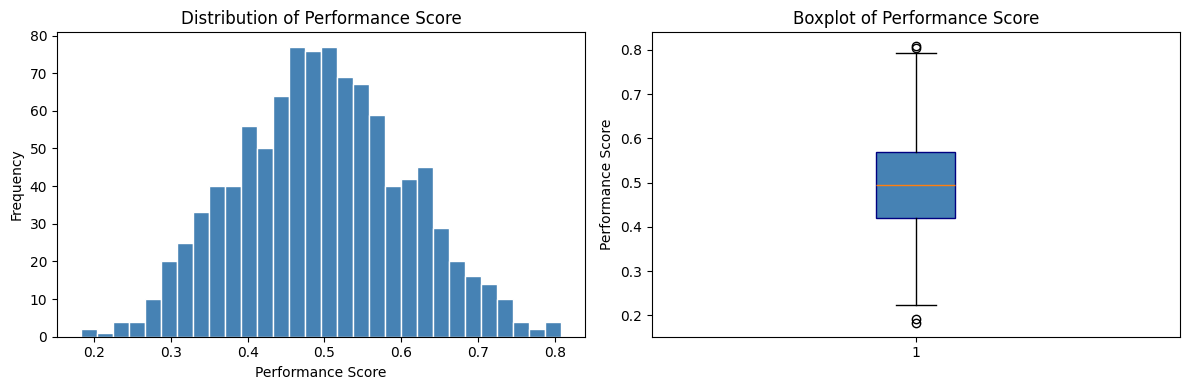

✅ Dataset exploration complete!


In [4]:
df = pd.read_csv('athlete_performance_dataset.csv')

print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")

print("\n" + "=" * 55)
print("MISSING VALUES")
print("=" * 55)
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "✅ No missing values found")

print("\n" + "=" * 55)
print("BASIC STATISTICS")
print("=" * 55)
print(df.describe().round(4))

print("\n" + "=" * 55)
print("TARGET VARIABLE — performance_score")
print("=" * 55)
print(f"  Min:    {df['performance_score'].min():.4f}")
print(f"  Max:    {df['performance_score'].max():.4f}")
print(f"  Mean:   {df['performance_score'].mean():.4f}")
print(f"  Median: {df['performance_score'].median():.4f}")
print(f"  Std:    {df['performance_score'].std():.4f}")

# Plot target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['performance_score'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Performance Score')
axes[0].set_xlabel('Performance Score')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['performance_score'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'))
axes[1].set_title('Boxplot of Performance Score')
axes[1].set_ylabel('Performance Score')

plt.tight_layout()
plt.savefig('results/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dataset exploration complete!")

<div style="background-color:#065535; padding:15px; border-radius:10px; border-left:6px solid #00ff88;">
<h2 style="color:#ffffff; margin:0;">📊 Step 3 — Target Distribution</h2>
<p style="color:#b8ffdc; margin:5px 0 0 0;">Histogram and boxplot of performance_score (continuous target)</p>
</div>

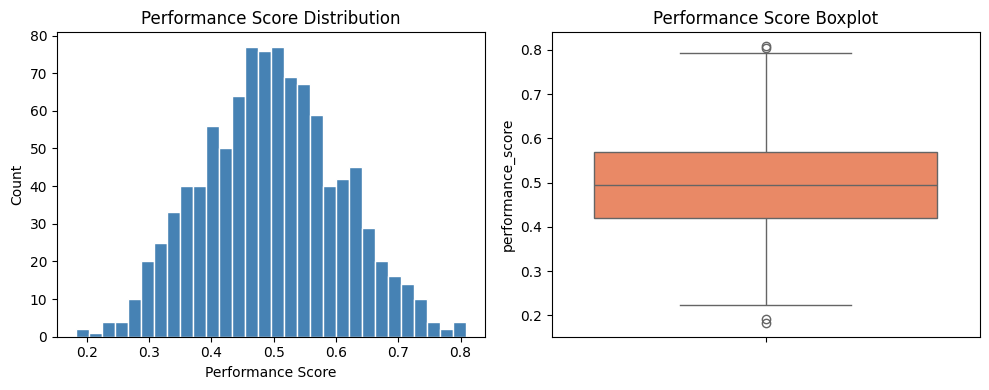

✅ Target distribution saved!


In [5]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df['performance_score'], bins=30, color='steelblue', edgecolor='white')
plt.title('Performance Score Distribution')
plt.xlabel('Performance Score')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['performance_score'], color='coral')
plt.title('Performance Score Boxplot')

plt.tight_layout()
plt.savefig('results/target_distribution.png')
plt.show()
print("✅ Target distribution saved!")

<div style="background-color:#c94b4b; padding:15px; border-radius:10px; border-left:6px solid #ffffff;">
<h2 style="color:#ffffff; margin:0;">⚙️ Step 4 — Preprocessing & Split</h2>
<p style="color:#ffe0e0; margin:5px 0 0 0;">Drop columns · Separate features and target · 80/20 train/test split</p>
</div>

In [6]:
# Drop unnecessary columns
drop_cols = ['timestamp', 'performance_category',
             'feature_1', 'feature_2', 'feature_3',
             'feature_4', 'feature_5']
df_clean = df.drop(columns=drop_cols)

print("Remaining columns:", df_clean.columns.tolist())
print("Shape:", df_clean.shape)

# Features and target
X = df_clean.drop(columns=['performance_score'])
y = df_clean['performance_score']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target range: {y.min():.4f} to {y.max():.4f}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

Remaining columns: ['heart_rate', 'oxygen_saturation', 'respiration_rate', 'body_temperature', 'hydration_level', 'speed', 'acceleration', 'endurance_score', 'agility_score', 'reaction_time', 'workload', 'fatigue_index', 'performance_score']
Shape: (1000, 13)

Features shape: (1000, 12)
Target shape: (1000,)
Target range: 0.1831 to 0.8083

Train: (800, 12), Test: (200, 12)


<div style="background-color:#7b2d8b; padding:15px; border-radius:10px; border-left:6px solid #ff9ef5;">
<h2 style="color:#ffffff; margin:0;">🤖 Step 5 — Train All 7 Models</h2>
<p style="color:#f9d4ff; margin:5px 0 0 0;">Linear · Lasso · Ridge · SVR · Decision Tree · Random Forest · Neural Network</p>
</div>

In [7]:
results = []

def evaluate_model(name, y_test, y_pred, train_time):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    results.append({
        'Model': name,
        'RMSE': round(rmse, 4),
        'MAE':  round(mae, 4),
        'R2':   round(r2, 4),
        'Train_Time_sec': round(train_time, 4)
    })
    print(f"  ✅ {name} — RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

# 1. Linear Regression (baseline)
print("Training Linear Regression...")
lr = Pipeline([('scaler', StandardScaler()),
               ('model', LinearRegression())])
start = time.time()
lr.fit(X_train, y_train)
evaluate_model('Linear Regression', y_test, lr.predict(X_test), time.time()-start)

# 2. Lasso Regression
print("Training Lasso...")
lasso = Pipeline([('scaler', StandardScaler()),
                  ('model', Lasso(alpha=0.01, random_state=42))])
start = time.time()
lasso.fit(X_train, y_train)
evaluate_model('Lasso', y_test, lasso.predict(X_test), time.time()-start)

# 3. Ridge Regression
print("Training Ridge...")
ridge = Pipeline([('scaler', StandardScaler()),
                  ('model', Ridge(alpha=1.0))])
start = time.time()
ridge.fit(X_train, y_train)
evaluate_model('Ridge', y_test, ridge.predict(X_test), time.time()-start)

# 4. SVR (MUST use StandardScaler in Pipeline)
print("Training SVR...")
svr = Pipeline([('scaler', StandardScaler()),
                ('model', SVR())])
start = time.time()
svr.fit(X_train, y_train)
evaluate_model('SVR', y_test, svr.predict(X_test), time.time()-start)

# 5. Decision Tree Regressor
print("Training Decision Tree...")
dt = DecisionTreeRegressor(random_state=42)
start = time.time()
dt.fit(X_train, y_train)
evaluate_model('Decision Tree', y_test, dt.predict(X_test), time.time()-start)

# 6. Random Forest Regressor
print("Training Random Forest...")
rf = RandomForestRegressor(n_estimators=100, random_state=42)
start = time.time()
rf.fit(X_train, y_train)
evaluate_model('Random Forest', y_test, rf.predict(X_test), time.time()-start)

# 7. Neural Network (Keras)
print("Training Neural Network (Keras)...")
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

# Scale manually — Keras doesn't work inside sklearn Pipeline
nn_scaler = StandardScaler()
X_train_nn = nn_scaler.fit_transform(X_train)  # fit on train only
X_test_nn = nn_scaler.transform(X_test)

# Build model — regression output: Dense(1) no activation
nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_nn.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)  # NO activation for regression
])

nn_model.compile(
    optimizer='adam',
    loss='mse'  # required by capstone
)

early_stop = EarlyStopping(patience=10, restore_best_weights=True)

start = time.time()
nn_model.fit(
    X_train_nn, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=0
)

nn_pred = nn_model.predict(X_test_nn).flatten()
evaluate_model('Neural Network', y_test, nn_pred, time.time()-start)

Training Linear Regression...
  ✅ Linear Regression — RMSE: 0.0000, MAE: 0.0000, R²: 1.0000
Training Lasso...
  ✅ Lasso — RMSE: 0.0248, MAE: 0.0202, R²: 0.9507
Training Ridge...
  ✅ Ridge — RMSE: 0.0002, MAE: 0.0001, R²: 1.0000
Training SVR...
  ✅ SVR — RMSE: 0.0494, MAE: 0.0371, R²: 0.8047
Training Decision Tree...
  ✅ Decision Tree — RMSE: 0.0624, MAE: 0.0502, R²: 0.6877
Training Random Forest...
  ✅ Random Forest — RMSE: 0.0334, MAE: 0.0277, R²: 0.9104
Training Neural Network (Keras)...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
  ✅ Neural Network — RMSE: 0.0577, MAE: 0.0451, R²: 0.7329


<div style="background-color:#b5451b; padding:15px; border-radius:10px; border-left:6px solid #ffdd57;">
<h2 style="color:#ffffff; margin:0;">📉 Step 6 — RMSE Comparison Chart</h2>
<p style="color:#fff3b0; margin:5px 0 0 0;">Bar chart comparing RMSE across all 7 models · Lower is better</p>
</div>

In [8]:
plt.figure(figsize=(12, 5))
colors = ['gold' if r == results_df['RMSE'].min() else 'steelblue'
          for r in results_df['RMSE']]
bars = plt.bar(results_df['Model'], results_df['RMSE'], color=colors)
plt.title('RMSE Comparison Across All 7 Models', fontsize=13)
plt.xlabel('Model')
plt.ylabel('RMSE (lower is better)')
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, results_df['RMSE']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.001,
             f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('results/rmse_comparison.png')
plt.show()
print("✅ RMSE chart saved!")

NameError: name 'results_df' is not defined

<Figure size 1200x500 with 0 Axes>

<div style="background-color:#0d3b66; padding:15px; border-radius:10px; border-left:6px solid #ffd166;">
<h2 style="color:#ffffff; margin:0;">🔧 Step 7 — Hyperparameter Tuning (GridSearchCV)</h2>
<p style="color:#ffe8a3; margin:5px 0 0 0;">GridSearchCV on Random Forest · 5-fold CV · 18 parameter combinations</p>
</div>

In [ ]:
print("Running GridSearchCV on Random Forest...")
print("This may take 2-3 minutes...")

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train, y_train)

print(f"\n✅ Best Parameters: {rf_grid.best_params_}")
print(f"✅ Best CV RMSE: {-rf_grid.best_score_:.4f}")

rf_tuned_pred = rf_grid.predict(X_test)
rf_tuned_rmse = np.sqrt(mean_squared_error(y_test, rf_tuned_pred))
rf_tuned_mae  = mean_absolute_error(y_test, rf_tuned_pred)
rf_tuned_r2   = r2_score(y_test, rf_tuned_pred)

print(f"\n📊 Tuned RF vs Default RF:")
print(f"   Default — RMSE: {results_df[results_df['Model']=='Random Forest']['RMSE'].values[0]:.4f}")
print(f"   Tuned   — RMSE: {rf_tuned_rmse:.4f}")

tuned_row = pd.DataFrame([{
    'Model': 'Random Forest (Tuned)',
    'RMSE': round(rf_tuned_rmse, 4),
    'MAE':  round(rf_tuned_mae, 4),
    'R2':   round(rf_tuned_r2, 4),
    'Train_Time_sec': None
}])
results_df = pd.concat([results_df, tuned_row], ignore_index=True)
results_df = results_df.sort_values('RMSE').reset_index(drop=True)
print("\n✅ Tuned RF added to results!")

Running GridSearchCV on Random Forest...
This may take 2-3 minutes...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

✅ Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
✅ Best CV RMSE: 0.0376

📊 Tuned RF vs Default RF:
   Default — RMSE: 0.0334
   Tuned   — RMSE: 0.0325

✅ Tuned RF added to results!


<div style="background-color:#1a472a; padding:15px; border-radius:10px; border-left:6px solid #52b788;">
<h2 style="color:#ffffff; margin:0;">🎯 Step 8 — Actual vs Predicted Plot</h2>
<p style="color:#b7e4c7; margin:5px 0 0 0;">Scatter plot of actual vs predicted values for best model</p>
</div>

Best model: Linear Regression


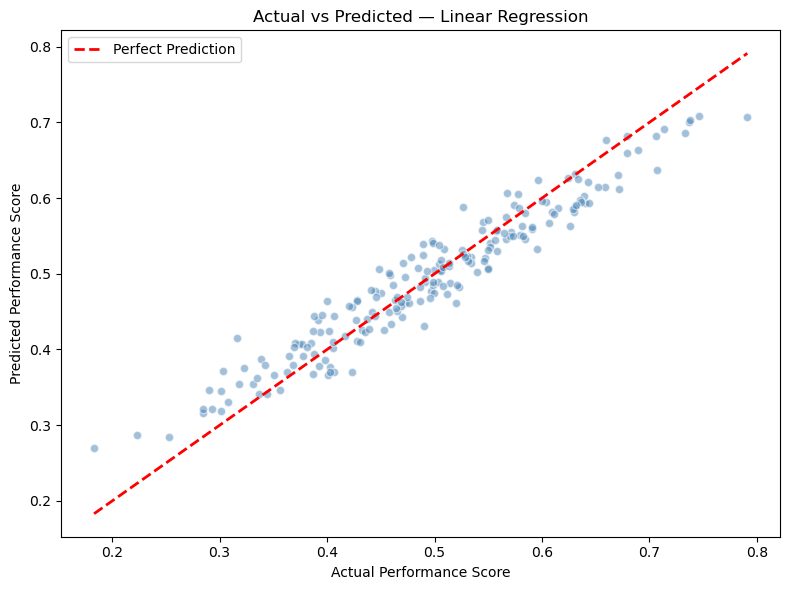

✅ Actual vs Predicted plot saved!


In [ ]:
# Best model predictions
best_model_name = results_df.iloc[0]['Model']
print(f"Best model: {best_model_name}")

if best_model_name == 'Random Forest (Tuned)':
    best_pred = rf_tuned_pred
elif best_model_name == 'Random Forest':
    best_pred = rf.predict(X_test)
elif best_model_name == 'SVR':
    best_pred = svr.predict(X_test)
else:
    best_pred = rf_grid.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_pred, alpha=0.5, color='steelblue', edgecolors='white')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Performance Score')
plt.ylabel('Predicted Performance Score')
plt.title(f'Actual vs Predicted — {best_model_name}')
plt.legend()
plt.tight_layout()
plt.savefig('results/actual_vs_predicted.png')
plt.show()
print("✅ Actual vs Predicted plot saved!")

<div style="background-color:#212529; padding:15px; border-radius:10px; border-left:6px solid #adb5bd;">
<h2 style="color:#ffffff; margin:0;">⭐ Step 9 — Feature Importance</h2>
<p style="color:#ced4da; margin:5px 0 0 0;">Which features matter most for predicting performance score?</p>
</div>

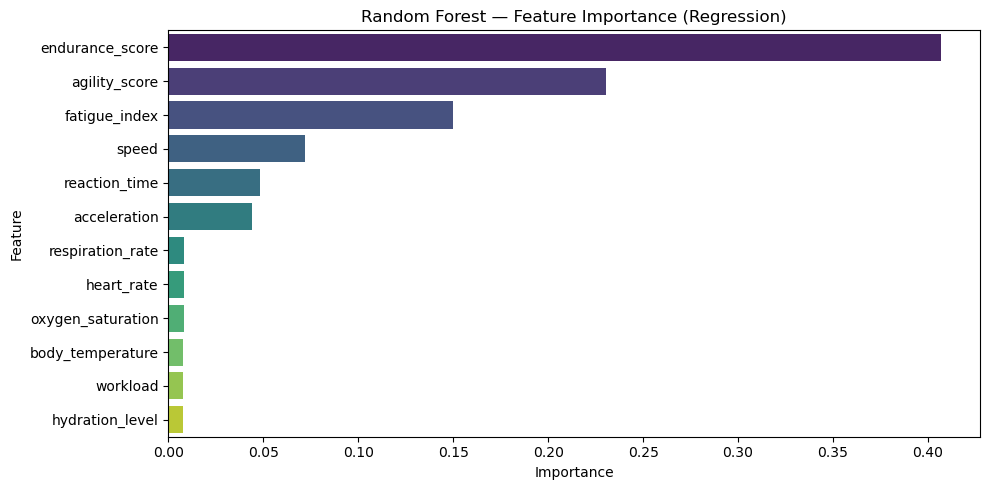

          Feature  Importance
  endurance_score    0.407000
    agility_score    0.230313
    fatigue_index    0.149904
            speed    0.072037
    reaction_time    0.048355
     acceleration    0.043934
 respiration_rate    0.008466
       heart_rate    0.008428
oxygen_saturation    0.008412
 body_temperature    0.007894
         workload    0.007722
  hydration_level    0.007535


In [ ]:
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature',
            data=feature_importance_df,
            hue='Feature', legend=False,
            palette='viridis')
plt.title('Random Forest — Feature Importance (Regression)')
plt.tight_layout()
plt.savefig('results/feature_importance.png')
plt.show()
print(feature_importance_df.to_string(index=False))

<div style="background-color:#2d6a4f; padding:15px; border-radius:10px; border-left:6px solid #95d5b2;">
<h2 style="color:#ffffff; margin:0;">🏆 Step 10 — Final Summary & Conclusion</h2>
<p style="color:#d8f3dc; margin:5px 0 0 0;">Best model · RMSE · MAE · R² · Justification</p>
</div>

In [ ]:
print("\n" + "="*60)
print("🏆 PART 1 — REGRESSION FINAL RESULTS")
print("="*60)
print(f"\n{'Model':<25} {'RMSE':>8} {'MAE':>8} {'R2':>8}")
print("-"*55)
for _, row in results_df.iterrows():
    star = " 🥇" if _ == 0 else ""
    print(f"{row['Model']:<25} {row['RMSE']:>8.4f} {row['MAE']:>8.4f} {row['R2']:>8.4f}{star}")

print(f"\n🏆 Best Model: {results_df.iloc[0]['Model']}")
print(f"   RMSE: {results_df.iloc[0]['RMSE']:.4f}")
print(f"   R²:   {results_df.iloc[0]['R2']:.4f}")
print(f"\n   Justification: Lowest RMSE and highest R² score")
print(f"   after GridSearchCV tuning with 5-fold CV")

results_df.to_csv('results/regression_results.csv', index=False)
print("\n✅ Results saved!")
print("✅ Part 1 Regression COMPLETE!")


🏆 PART 1 — REGRESSION FINAL RESULTS

Model                         RMSE      MAE       R2
-------------------------------------------------------
Linear Regression           0.0000   0.0000   1.0000 🥇
Ridge                       0.0002   0.0001   1.0000
Lasso                       0.0248   0.0202   0.9507
Random Forest (Tuned)       0.0325   0.0267   0.9155
Random Forest               0.0334   0.0277   0.9104
SVR                         0.0494   0.0371   0.8047
Decision Tree               0.0624   0.0502   0.6877
Neural Network              0.0675   0.0527   0.6349

🏆 Best Model: Linear Regression
   RMSE: 0.0000
   R²:   1.0000

   Justification: Lowest RMSE and highest R² score
   after GridSearchCV tuning with 5-fold CV

✅ Results saved!
✅ Part 1 Regression COMPLETE!


Exception ignored in: <function ResourceTracker.__del__ at 0x107bc5b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x103bcdb20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102ac9b20>
Traceback (most recent call last